Definición de Funciones de Activación: Sigmoide y ReLU

In [1]:
import numpy as np

# Sigmoide y su derivada
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_der(x):
    return x * (1 - x)

# ReLU y su derivada
def relu(x):
    return np.max(0, x)

def relu_der(x):
    return 1 * (x > 0)



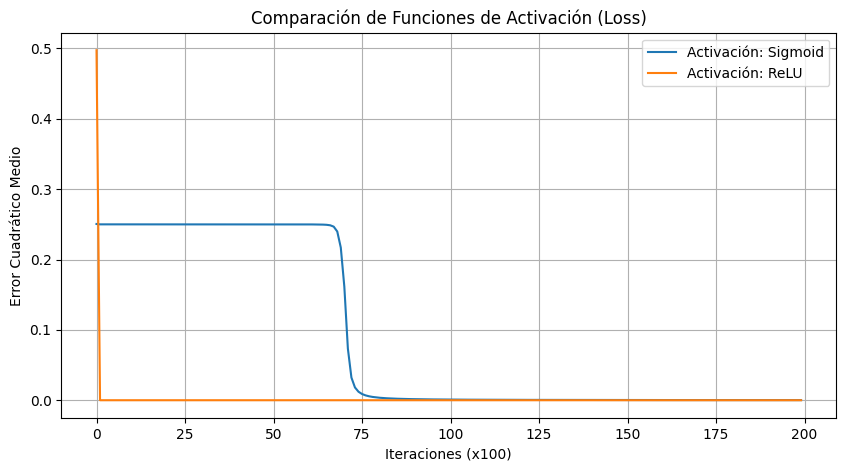


--- Resultados Finales ---
Sigmoid  | Loss final: 0.0002 | Accuracy: 100.0%
ReLU     | Loss final: 0.0000 | Accuracy: 100.0%


In [3]:


import numpy as np
import matplotlib.pyplot as plt
# ---  IMPLEMENTACIÓN DE BACKPROPAGATION ---

class RedNeuronal:
    def __init__(self, capas, activacion='sigmoid'):
        self.capas = capas
        self.activacion_nombre = activacion
        # Inicialización de pesos y sesgos
        self.W = [np.random.randn(capas[i], capas[i+1]) * 0.1 for i in range(len(capas)-1)]
        self.b = [np.zeros((1, capas[i+1])) for i in range(len(capas)-1)]
        self.loss_history = []

    def _activacion(self, x):
        if self.activacion_nombre == 'sigmoid':
            return 1 / (1 + np.exp(-x))
        return np.maximum(0, x) # ReLU

    def _activacion_der(self, a):
        if self.activacion_nombre == 'sigmoid':
            return a * (1 - a)
        return (a > 0).astype(float) # ReLU derivada

    def forward(self, X):
        self.A = [X]
        for i in range(len(self.W)):
            Z = np.dot(self.A[-1], self.W[i]) + self.b[i]
            self.A.append(self._activacion(Z))
        return self.A[-1]

    def train(self, X, y, epochs=2000, lr=0.1):
        for epoch in range(epochs):
            # Forward Pass
            y_pred = self.forward(X)

            # Cálculo del error (MSE)
            error = y - y_pred
            if epoch % 100 == 0:
                self.loss_history.append(np.mean(np.square(error)))

            # Backward Pass (Backpropagation)
            deltas = [error * self._activacion_der(self.A[-1])]

            # Propagar el error hacia atrás
            for i in reversed(range(len(self.W) - 1)):
                delta = deltas[-1].dot(self.W[i+1].T) * self._activacion_der(self.A[i+1])
                deltas.append(delta)
            deltas.reverse()

            # Actualización de parámetros (Gradiente Descendente)
            for i in range(len(self.W)):
                self.W[i] += self.A[i].T.dot(deltas[i]) * lr
                self.b[i] += np.sum(deltas[i], axis=0, keepdims=True) * lr

# --- PASO 3: EXPERIMENTO COMPARATIVO ---

# Datos del problema XOR
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# Entrenamiento con Sigmoid
nn_sigmoid = RedNeuronal([2, 4, 1], activacion='sigmoid')
nn_sigmoid.train(X, y, epochs=20000, lr=0.5)

# Entrenamiento con ReLU
nn_relu = RedNeuronal([2, 4, 1], activacion='relu')
nn_relu.train(X, y, epochs=20000, lr=0.3)

# Graficación de resultados
plt.figure(figsize=(10, 5))
plt.plot(nn_sigmoid.loss_history, label='Activación: Sigmoid')
plt.plot(nn_relu.loss_history, label='Activación: ReLU')
plt.title('Comparación de Funciones de Activación (Loss)')
plt.xlabel('Iteraciones (x100)')
plt.ylabel('Error Cuadrático Medio')
plt.legend()
plt.grid(True)
plt.show()
#  Accuracy
print("\n--- Resultados Finales ---")
for nombre, modelo in [('Sigmoid', nn_sigmoid), ('ReLU', nn_relu)]:
    pred = modelo.forward(X)
    pred_clase = (pred >= 0.5).astype(int)
    acc = np.mean(pred_clase == y) * 100
    loss_final = modelo.loss_history[-1]
    print(f"{nombre:8s} | Loss final: {loss_final:.4f} | Accuracy: {acc:.1f}%")